# Classical ML on the Wisconsin Breast Cancer dataset

We train four classic models — **logistic regression, random forest, SVM, and a neural network** — to tell malignant tumors from benign ones, compare them, then use **SHAP** to explain *why* they predict what they do.

The data is the [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) set: 569 tumors, each described by 30 features computed from a digitized image of a fine-needle aspirate (mean radius, texture, area, …). `scikit-learn` ships the identical dataset, so we load it from there — no download needed.

## Setup

Everything we need, imported once up front.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the data

Each row is a tumor; `target` is 0 = malignant, 1 = benign. We drop it into a DataFrame just to look at it.

In [9]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


How many of each class? The set leans toward benign, so we'll keep that ratio when we split.

In [10]:
df["target"].value_counts().rename({0: "malignant", 1: "benign"})

target
benign       357
malignant    212
Name: count, dtype: int64

## Split and scale

We hold out 25% for testing. Logistic regression, SVM, and the neural net all care about feature scale, so we standardize: fit the scaler on the **training** data only, then apply it to both — otherwise the test set leaks information into training.

We keep the data as labeled DataFrames so the models are fitted *with* feature names. That makes the SHAP plots later read real feature names — and avoids scikit-learn's "fitted without feature names" warning.

In [11]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

sc = StandardScaler().fit(Xtr)
Xtr = pd.DataFrame(sc.transform(Xtr), columns=X.columns, index=Xtr.index)
Xte = pd.DataFrame(sc.transform(Xte), columns=X.columns, index=Xte.index)
Xtr.shape, Xte.shape

((426, 30), (143, 30))

## 1. Logistic regression

A linear model: it learns a weighted sum of the features squashed through a sigmoid into a probability. Simple, fast, and a surprisingly strong baseline here.

In [12]:
logreg = LogisticRegression(max_iter=5000).fit(Xtr, ytr)
accuracy_score(yte, logreg.predict(Xte))

0.958041958041958

## 2. Random forest

Many decision trees, each grown on a random subset of rows and features; they vote. It captures non-linear boundaries and needs no scaling (we feed it the scaled data anyway, just for consistency).

In [13]:
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(Xtr, ytr)
accuracy_score(yte, rf.predict(Xte))

0.9440559440559441

## 3. Support vector machine

Finds the boundary with the widest margin between the two classes. The RBF kernel lets that boundary curve instead of staying a straight line. Scaling matters a lot for SVMs. We set `probability=True` so the model can report class probabilities — SHAP will need them later.

In [14]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=0).fit(Xtr, ytr)
accuracy_score(yte, svm.predict(Xte))

0.958041958041958

## 4. Neural network

A small multilayer perceptron — two hidden layers of 32 and 16 units — trained by backprop. With this little data it won't dominate, but it follows the exact same fit/predict workflow.

In [15]:
nn = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0).fit(Xtr, ytr)
accuracy_score(yte, nn.predict(Xte))

0.958041958041958

## Compare them

We collect the four fitted models in a dict and score each on the test set. This is the one spot a loop earns its keep — the same line repeated four times.

In [16]:
models = {"logistic": logreg, "random forest": rf, "svm": svm, "neural net": nn}
acc = {name: accuracy_score(yte, m.predict(Xte)) for name, m in models.items()}
pd.Series(acc).sort_values(ascending=False)

logistic         0.958042
svm              0.958042
neural net       0.958042
random forest    0.944056
dtype: float64

Same thing as a bar chart (zoomed in, since everything scores above 0.9):

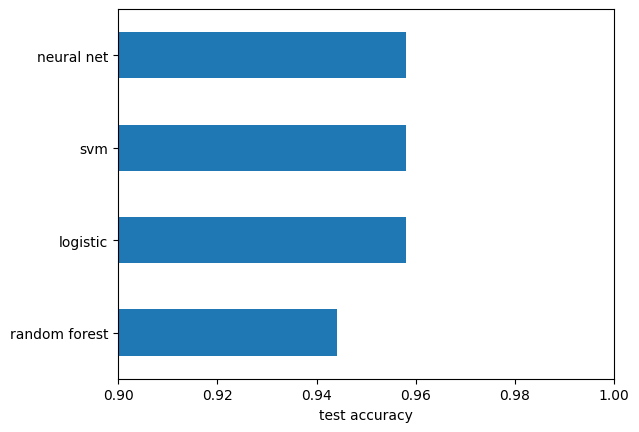

In [17]:
pd.Series(acc).sort_values().plot.barh()
plt.xlabel("test accuracy")
plt.xlim(0.9, 1.0);

## A closer look at the best model

Accuracy alone hides *which* mistakes a model makes. Missing a malignant tumor (a false "benign") is the costly error here, so for the top model we read the confusion matrix and per-class precision/recall.

In [18]:
best = max(acc, key=acc.get)
yp = models[best].predict(Xte)
print(best)
print(confusion_matrix(yte, yp))
print(classification_report(yte, yp, target_names=["malignant", "benign"]))

logistic
[[50  3]
 [ 3 87]]
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        53
      benign       0.97      0.97      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



## Explaining the predictions with SHAP

Accuracy tells us *how often* a model is right; [SHAP](https://shap.readthedocs.io) tells us *why* it decides what it does. SHAP gives each feature a contribution — its fair share of pushing a prediction away from the model's average output — using Shapley values from game theory. We read it two ways:

- **Global** — aggregate over many tumors to see which features drive a model overall.
- **Local** — a single tumor, to see why the model called it malignant or benign.

We treat every model as a black box from the 30 features to **P(benign)**, so one piece of code explains all four. (That's why we gave the SVM `probability=True`.)

In [19]:
import shap

feat = list(data.feature_names)
bg = shap.utils.sample(Xtr, 50, random_state=0)   # background "average" tumor
bg.shape

c:\Users\justi\anaconda3\envs\exlent2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(50, 30)

The one bit of reused logic: wrap a model as a function to P(benign) and return one SHAP value per feature. `[..., 1]` keeps the benign class.

In [20]:
def shap_vals(model, Xq):
    """SHAP values for P(benign) of `model` on the rows in Xq."""
    ex = shap.Explainer(model.predict_proba, bg)
    return ex(Xq)[..., 1]  # SHAP values for P(benign)

### Global: what drives each model

We explain 60 test tumors per model. This takes a few seconds — SHAP probes each model many times to estimate the contributions.

In [21]:
Xg = Xte.iloc[:100]
sv = {name: shap_vals(m, Xg) for name, m in models.items()}
{name: e.values.shape for name, e in sv.items()}

PermutationExplainer explainer: 101it [00:26,  2.42it/s]                         
PermutationExplainer explainer: 101it [00:18,  2.49it/s]                         


{'logistic': (100, 30),
 'random forest': (100, 30),
 'svm': (100, 30),
 'neural net': (100, 30)}

In a **beeswarm** each dot is one tumor; its horizontal position is that feature's SHAP value (right = pushed toward *benign*), and color is the feature's value (red = high, blue = low). Features are ordered by overall importance. One plot per model:

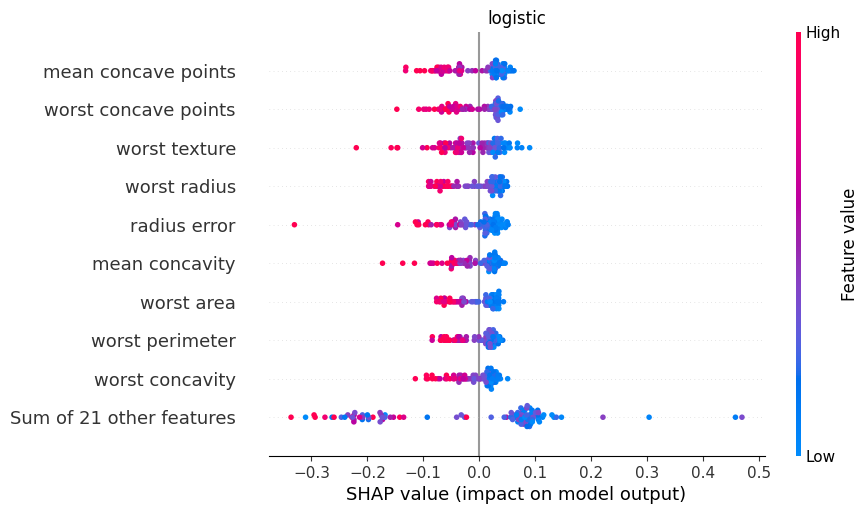

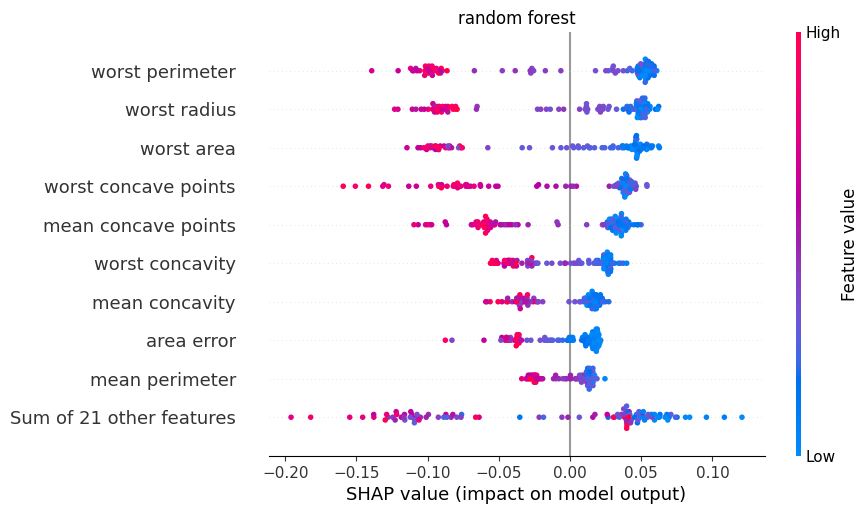

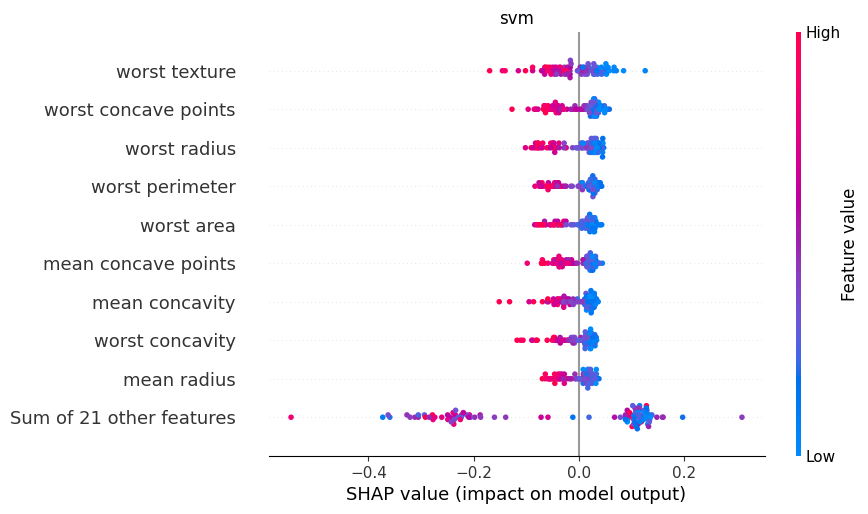

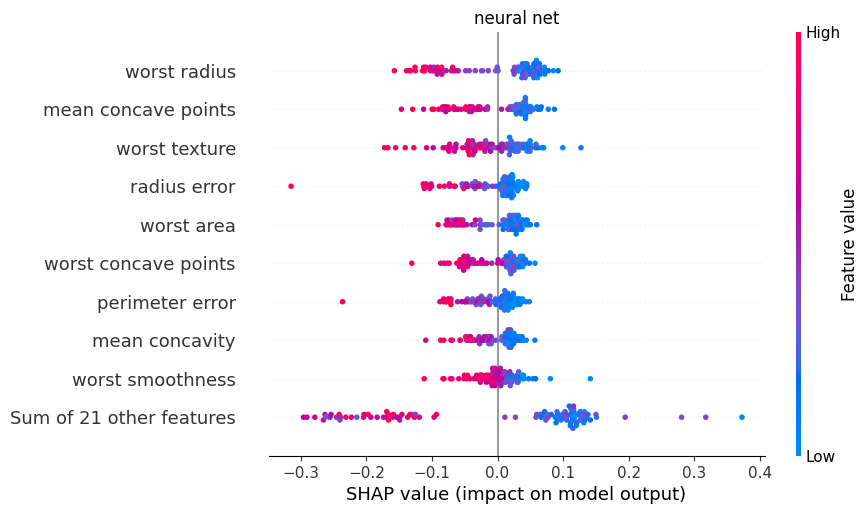

In [22]:
for name, e in sv.items():
    shap.plots.beeswarm(e, max_display=10, show=False)
    plt.title(name)
    plt.show()

Side by side, the top five features by mean |SHAP| for each model — the models mostly agree on what matters (the "worst" size and concavity measurements).

In [23]:
top = {name: pd.Series(np.abs(e.values).mean(0), index=feat).nlargest(5).index.tolist()
       for name, e in sv.items()}
pd.DataFrame(top)

,logistic,random forest,svm,neural net
0,mean concave points,worst perimeter,worst texture,worst radius
1,worst concave points,worst radius,worst concave points,mean concave points
2,worst texture,worst area,worst radius,worst texture
3,worst radius,worst concave points,worst perimeter,radius error
4,radius error,mean concave points,worst area,worst area


### Local: why these individual tumors?

We pick three test tumors — a true malignant, a true benign, and one the best model got wrong — and explain each with the best model.

In [24]:
i_mal = np.where(yte == 0)[0][0]
i_ben = np.where(yte == 1)[0][0]
i_err = np.where(models[best].predict(Xte) != yte)[0][0]
sel = [int(i_mal), int(i_ben), int(i_err)]
sel

[1, 0, 12]

A **waterfall** reads bottom-to-top: starting from the baseline P(benign), each feature pushes the prediction up (toward benign) or down (toward malignant) until it reaches the model's output for that one tumor.

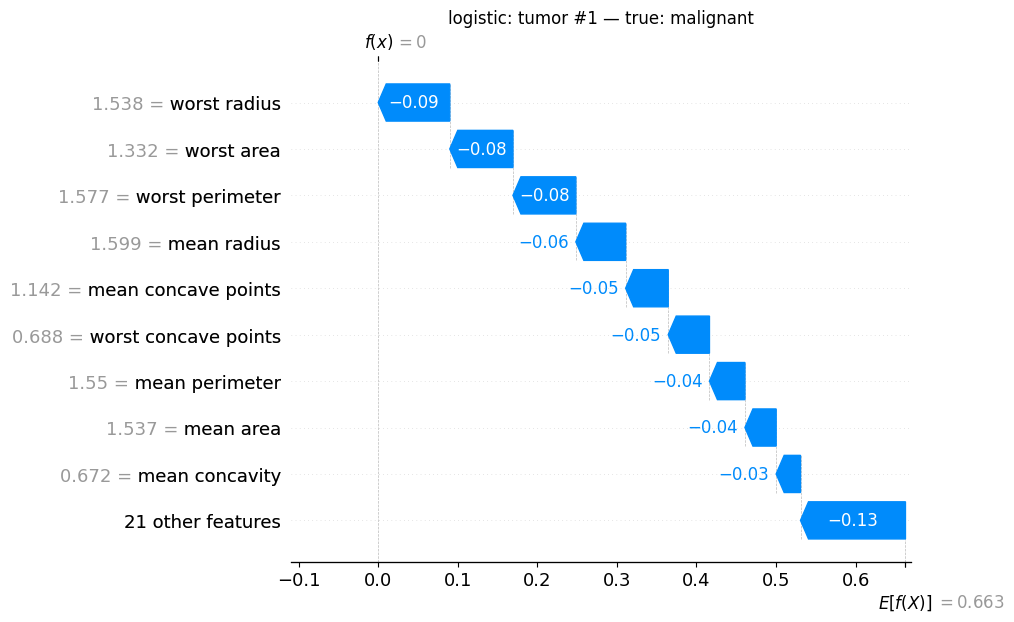

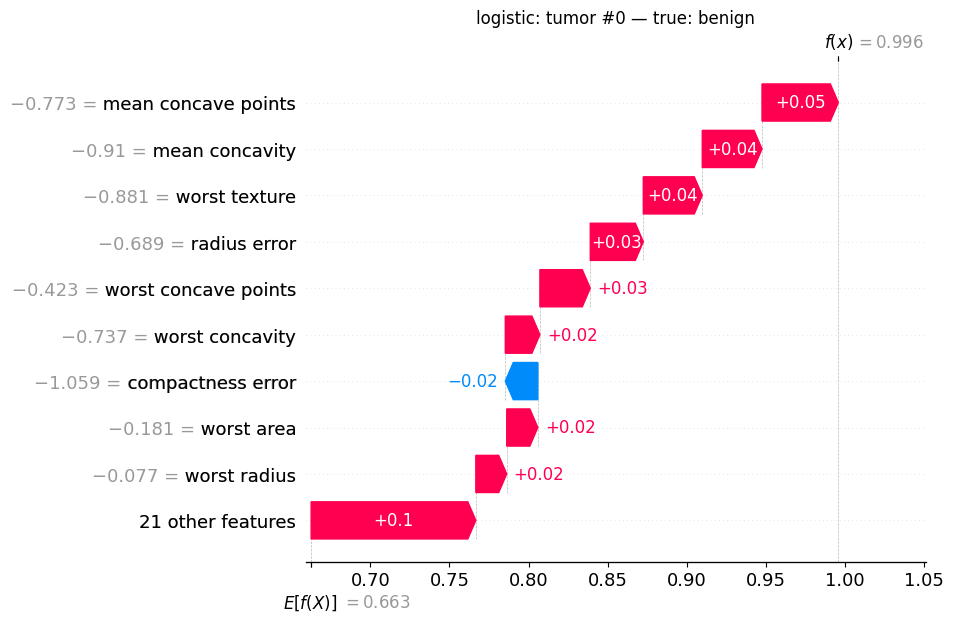

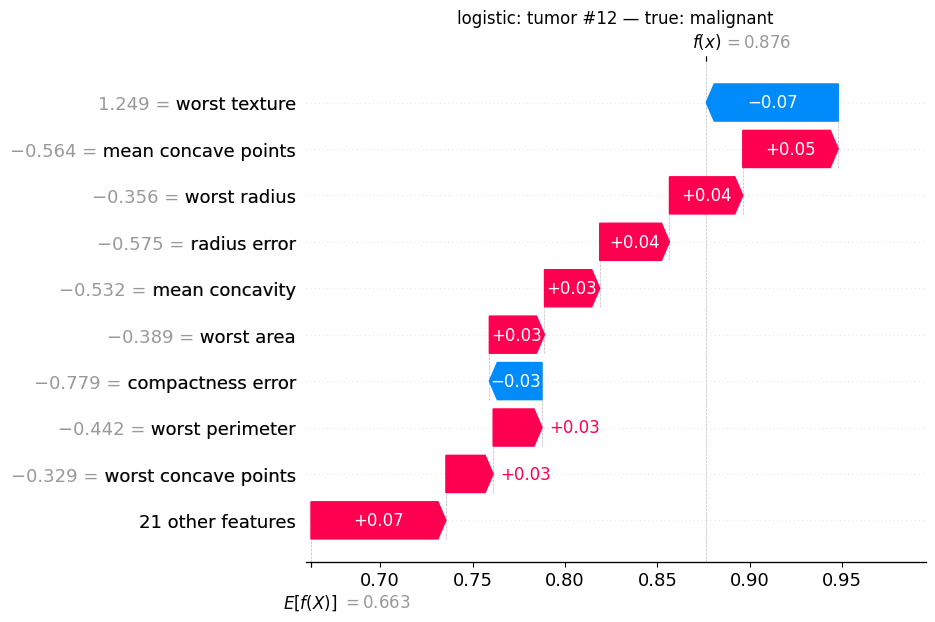

In [25]:
e_loc = shap_vals(models[best], Xte.iloc[sel])
for j, idx in enumerate(sel):
    shap.plots.waterfall(e_loc[j], max_display=10, show=False)
    truth = "malignant" if yte[idx] == 0 else "benign"
    plt.title(f"{best}: tumor #{idx} — true: {truth}")
    plt.show()

## Permutation importance

SHAP attributes individual *predictions*. **Permutation importance** asks a blunter question about the *whole model*: shuffle one feature's values across the test set — destroying its information — and measure how much accuracy drops. A big drop means the model leaned on that feature. It's model-agnostic and measured on real predictions, so it's a good cross-check on the SHAP rankings.

In [26]:
from sklearn.inspection import permutation_importance

pi = {name: permutation_importance(m, Xte, yte, n_repeats=10, random_state=0)
      for name, m in models.items()}
imp = pd.DataFrame({name: pd.Series(r.importances_mean, index=feat) for name, r in pi.items()})
imp.shape

(30, 4)

The five features each model relies on most (mean accuracy drop when shuffled). Compare these with the SHAP top-five above — mostly the same cast in a different order, since the two methods measure different things.

In [27]:
pd.DataFrame({name: imp[name].nlargest(5).index.tolist() for name in imp})

,logistic,random forest,svm,neural net
0,radius error,worst perimeter,perimeter error,worst texture
1,mean concave points,worst area,radius error,radius error
2,worst texture,worst concave points,mean concavity,perimeter error
3,mean concavity,mean concavity,worst area,worst smoothness
4,worst smoothness,mean concave points,worst texture,worst radius


For the best model, the top 10 features with the spread across the 10 shuffles (error bars):

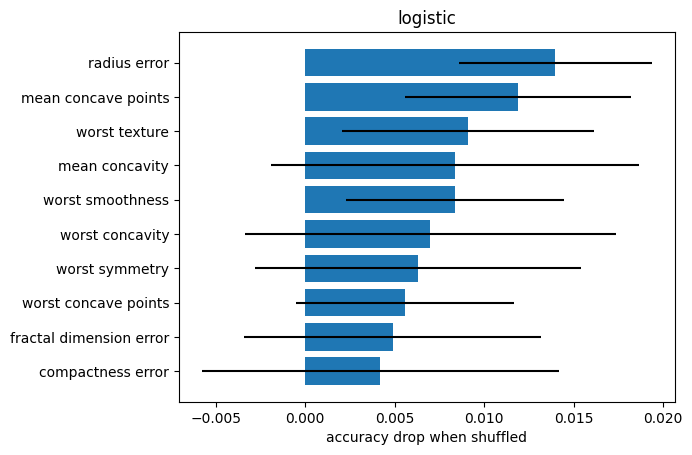

In [28]:
r = pi[best]
order = r.importances_mean.argsort()[::-1][:10]
plt.barh([feat[i] for i in order][::-1],
         r.importances_mean[order][::-1],
         xerr=r.importances_std[order][::-1])
plt.xlabel("accuracy drop when shuffled")
plt.title(best);
plt.show()